In [3]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [13]:
def twiss_scan(line: xt.Line, delta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    tw0 = line.twiss4d(delta0=0.0)
    rows: list[tuple[float, float, float]] = [(0.0, float(tw0.qx), float(tw0.qy))]

    co_prev = tw0.particle_on_co
    neg_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid < 0][::-1]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            neg_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            neg_rows.append((float(delta), np.nan, np.nan))

    co_prev = tw0.particle_on_co
    pos_rows: list[tuple[float, float, float]] = []
    for delta in delta_grid[delta_grid > 0]:
        try:
            tw = line.twiss4d(delta0=float(delta), co_guess=co_prev)
            co_prev = tw.particle_on_co
            pos_rows.append((float(delta), float(tw.qx), float(tw.qy)))
        except Exception as e:
            pos_rows.append((float(delta), np.nan, np.nan))

    rows = neg_rows[::-1] + rows + pos_rows
    d = np.array([r[0] for r in rows], dtype=float)
    qx = np.array([r[1] for r in rows], dtype=float)
    qy = np.array([r[2] for r in rows], dtype=float)
    return d, qx, qy

In [14]:
#Data MD
with open("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit_v2/tune_poly_coefficients.json") as f:
      coeffs = json.load(f)

qx_coeff = np.array(coeffs["Qx_kickH"]["poly4"]["coefficients_high_to_low"])
qy_coeff = np.array(coeffs["Qy_kickV"]["poly4"]["coefficients_high_to_low"])

qx0 = qx_coeff[4] + 20
qx1 = qx_coeff[3]
qx2 = qx_coeff[2]
qx3 = qx_coeff[1]
qx4 = qx_coeff[0]

qy0 = qy_coeff[4] + 20
qy1 = qy_coeff[3]
qy2 = qy_coeff[2]
qy3 = qy_coeff[1]
qy4 = qy_coeff[0]

print(qx0, qx1, qx2, qx3, qx4)
print(qy0, qy1, qy2, qy3, qy4)

20.135651385655766 1.3853870500626928 -485.37111311696805 -98753.84952493232 39044666.236123264
20.178849830100283 1.3404718005055556 -732.9755010775554 59867.04451836026 19608320.65383154


In [29]:
3/20.13

0.14903129657228018

In [2]:
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}

error_variant = "all"

In [15]:
# New Model
line = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env = line.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env.vars["qph_setvalue"] = 0.0
env.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*1.29536169e-05,   b4*0.,       b5*-2.10603563,  b6*0.])
for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-2.44799746e-05,  b4*0.,       b5*-2.41741244e-01,  b6*0.])
for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-6.56961423e-02,  b5*0.,     b6*1.13848638e+03])
for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*2.4785736e-01, b5*0.,     b6*-7.9631362e+03])

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
line['actcse.31632'].voltage = 3.0e6

delta_grid = np.linspace(-3e-3, 3e-3, 41)
d_model, qx_model, qy_model = twiss_scan(line, delta_grid)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 1.799                             
Matching: model call n. 29 penalty = 6.0028e-03              
Optimize - end penalty:  0.00600279                            


In [16]:
# Model Hannes
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx0,       qy=qy0,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

delta_grid2 = np.linspace(-3e-3, 3e-3, 41)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 11.28                             
Matching: model call n. 44 penalty = 3.3032e-03              
Optimize - end penalty:  0.00330321                            


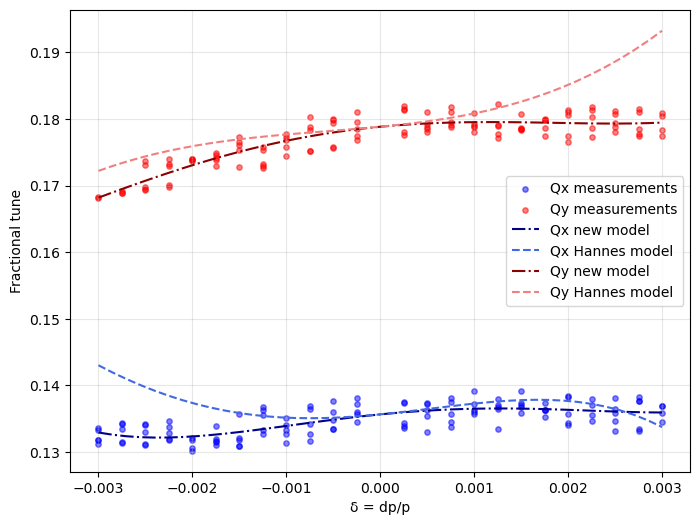

In [ ]:
#Comparison with new measurements
path = Path("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit/")
indiv   = pd.read_csv(path / "tune_data_individual.csv")
summary = pd.read_csv(path / "tune_data_summary.csv")

qx = indiv[indiv.plane == "Qx_kickH"]
qy = indiv[indiv.plane == "Qy_kickV"]

qx_good = qx[qx.good == 1]
qy_good = qy[qy.good == 1]

qx_sum = summary[summary.plane == "Qx_kickH"]
qy_sum = summary[summary.plane == "Qy_kickV"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(qx_good.delta, qx_good.tune, s=15, alpha=0.5, color='blue',label="Qx measurements")
ax.scatter(qy_good.delta, qy_good.tune, s=15, alpha=0.5, color='red', label="Qy measurements")

ax.plot(d_model, qx_model-20, color='darkblue', ls = '-.', label="Qx new model")
ax.plot(d_model2, qx_model2-20, color='royalblue', ls = '--', label="Qx Hannes model")
ax.plot(d_model, qy_model-20, color='darkred', ls = '-.', label="Qy new model")
ax.plot(d_model2, qy_model2-20, color='lightcoral', ls = '--', label="Qy Hannes model")

ax.grid(True, alpha=0.3)
ax.set_xlabel("δ = dp/p")
ax.set_ylabel("Fractional tune")
ax.legend()

In [26]:
Qx = 20.13
Qy = 20.173
# xi_x = 0.568
# xi_y = 0.084
xi_x = 0.051
xi_y = 0.019

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=Qx,       qy=Qy,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x*Qx, dqy=xi_y*Qy, tol=1e-2, tag="chrom"),
        ],
    )

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=Qx,       qy=Qy,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x*Qx, dqy=xi_y*Qy, tol=1e-2, tag="chrom"),
        ],
    )

delta_grid_v2 = np.linspace(-4e-3, 4e-3, 41)
d_model_v2, qx_model_v2, qy_model_v2 = twiss_scan(line, delta_grid_v2)
delta_grid2_v2 = np.linspace(-4e-3, 4e-3, 41)
d_model2_v2, qx_model2_v2, qy_model2_v2 = twiss_scan(line2, delta_grid2_v2)

                                             
Optimize - start penalty: 10.49                             
Matching: model call n. 29 penalty = 8.5901e-03              
Optimize - end penalty:  0.00859013                            
                                             
Optimize - start penalty: 10.49                             
Matching: model call n. 56 penalty = 3.5868e-03              
Optimize - end penalty:  0.00358677                            


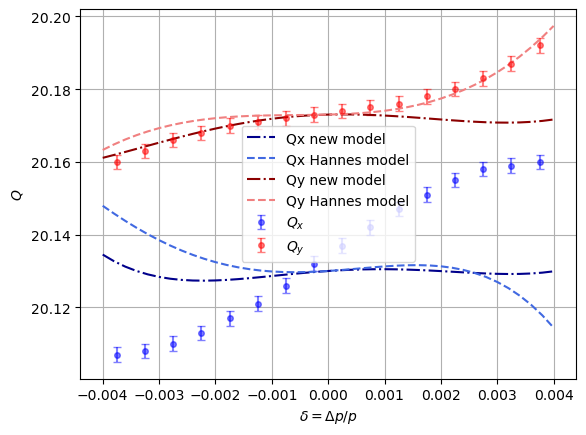

In [27]:
#Comparison with old measurements
# Load
with open('Hannes_measurements.json', 'r') as f:
    data = json.load(f)

# Extract
dx  = [d['dp_over_p'] for d in data['Qx_measurements']]
qx  = [d['Q']         for d in data['Qx_measurements']]
sex = [d['sigma']      for d in data['Qx_measurements']]

dy  = [d['dp_over_p'] for d in data['Qy_measurements']]
qy  = [d['Q']         for d in data['Qy_measurements']]
sey = [d['sigma']      for d in data['Qy_measurements']]

# Plot
fig, ax = plt.subplots()

ax.errorbar(dx, qx, yerr=sex, fmt='o', ms=4, alpha=0.5, color='blue', capsize=3, label=r'$Q_x$')
ax.errorbar(dy, qy, yerr=sey, fmt='o', ms=4, alpha=0.5, color='red',  capsize=3, label=r'$Q_y$')

ax.plot(d_model_v2, qx_model_v2, color='darkblue', ls = '-.', label="Qx new model")
ax.plot(d_model2_v2, qx_model2_v2, color='royalblue', ls = '--', label="Qx Hannes model")
ax.plot(d_model_v2, qy_model_v2, color='darkred', ls = '-.', label="Qy new model")
ax.plot(d_model2_v2, qy_model2_v2, color='lightcoral', ls = '--', label="Qy Hannes model")

ax.set_xlabel(r'$\delta = \Delta p / p$')
ax.set_ylabel(r'$Q$')
ax.legend()
ax.grid(True)

# plt.tight_layout()
# plt.show()

# Sweep test with new line

# Trying other chroma values with Hannes model

In [30]:
xi_x = 0.155
xi_y = 0.13
Qx = qx0
Qy = qy0

In [40]:
# Model Hannes
line2 = xt.load("sps_with_aperture_inj_q20_beam_sagitta4.json")

env2 = line2.env
error_variants = {
    "dipole_b3":               [0, 0, 1, 0, 0, 0],
    "dipole_b5":               [0, 0, 0, 0, 1, 0],
    "dipole_b3b5":             [0, 0, 1, 0, 1, 0],
    "quadrupole_b4":           [0, 0, 0, 1, 0, 0],
    "quadrupole_b6":           [0, 0, 0, 0, 0, 1],
    "quadrupole_b4b6":         [0, 0, 0, 1, 0, 1],
    "dipole_b3_quadrupole_b4": [0, 0, 1, 1, 0, 0],
    "all":                     [0, 0, 1, 1, 1, 1],
}
b1, b2, b3, b4, b5, b6 = error_variants['all']
tte = env2.elements.get_table()
mask_rbends = tte.element_type == "RBend"
mask_quads  = tte.element_type == "Quadrupole"

mba = tte.rows[mask_rbends].rows["mba.*"].name
mbb = tte.rows[mask_rbends].rows["mbb.*"].name
qf  = tte.rows[mask_quads].rows["qf.*"].name
qd  = tte.rows[mask_quads].rows["qd.*"].name

env2.vars["qph_setvalue"] = 0.0
env2.vars["qpv_setvalue"] = 0.0

for nn in mba:
    env2[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3,   b4*0.,       b5*-5.74,  b6*0.])
for nn in mbb:
    env2[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3,  b4*0.,       b5*-5.10,  b6*0.])
for nn in qf:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*0.75e-1,  b5*0.,     b6*-0.87e3])
for nn in qd:
    env2[nn].knl = np.array([b1*0., b2*0., b3*0.,        b4*-2.03e-1, b5*0.,     b6*2.04e3])

line2.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"],                step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-7, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=Qx,       qy=Qy,     tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x*Qx, dqy=xi_y*Qy, tol=1e-2, tag="chrom"),
        ],
    )

cavity_elements, cavity_names = line2.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line2[name].frequency = 200e6
    line2[name].lag = 180
    line2[name].voltage = 0
line2['actcse.31632'].voltage = 3.0e6

# delta_grid2 = np.linspace(-3e-3, 3e-3, 41)
delta_grid2 = np.unique(qx_good.delta)
d_model2, qx_model2, qy_model2 = twiss_scan(line2, delta_grid2)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 9.53                              
Matching: model call n. 69 penalty = 4.9514e-03              
Optimize - end penalty:  0.00495143                            


In [43]:
qx_good.tune

0      0.131812
1      0.133322
2      0.133580
3      0.131269
4      0.131847
         ...   
113    0.137616
114    0.136859
115    0.134564
116    0.136899
117    0.135913
Name: tune, Length: 117, dtype: float64

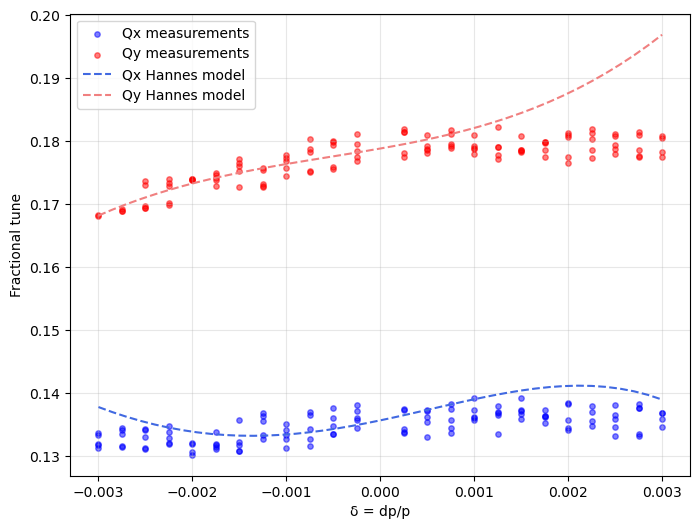

In [ ]:
#Comparison with new measurements
path = Path("/Users/lisepauwels/phd/data/sps-measurements/results_chroma/analysis2/tune_fit/")
indiv   = pd.read_csv(path / "tune_data_individual.csv")
summary = pd.read_csv(path / "tune_data_summary.csv")

qx = indiv[indiv.plane == "Qx_kickH"]
qy = indiv[indiv.plane == "Qy_kickV"]

qx_good = qx[qx.good == 1]
qy_good = qy[qy.good == 1]

qx_sum = summary[summary.plane == "Qx_kickH"]
qy_sum = summary[summary.plane == "Qy_kickV"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(qx_good.delta, qx_good.tune, s=15, alpha=0.5, color='blue',label="Qx measurements")
ax.scatter(qy_good.delta, qy_good.tune, s=15, alpha=0.5, color='red', label="Qy measurements")

# ax.plot(d_model, qx_model-20, color='darkblue', ls = '-.', label="Qx new model")
ax.plot(d_model2, qx_model2-20, color='royalblue', ls = '--', label="Qx Hannes model")
# ax.plot(d_model, qy_model-20, color='darkred', ls = '-.', label="Qy new model")
ax.plot(d_model2, qy_model2-20, color='lightcoral', ls = '--', label="Qy Hannes model")

ax.grid(True, alpha=0.3)
ax.set_xlabel("δ = dp/p")
ax.set_ylabel("Fractional tune")
ax.legend()

In [ ]:
def residual2(qx_meas, qy_meas, qx_model, qy_model):
    res_qx = (qx_meas - qx_model)**2
    res_qy = (qy_meas - qy_model)**2
    return res_qx, res_qy

In [ ]:
res2x = 0.0
res2y = 0.0
for i, dd in enumerate(delta_grid2):
    for tt in qx_good.tune[qx_good.delta == dd]:
        res2x += (qx_model2[i] -20 - tt)**2
    for tt in qy_good.tune[qy_good.delta == dd]:
        res2y += (qy_model2[i] -20 - tt)**2

In [45]:
res2x

np.float64(0.0012751760257805095)